# 09 — D9 `jump_model`: Statistical Jump Model (Nystrup et al., 2020)

Familia **CLUSTERING con regularización temporal** — Nystrup, Lindström & Madsen (2020),
*"Learning Hidden Markov Models with Persistent States by Penalizing Jumps"*.

Un **Statistical Jump Model (SJM)** es un clustering de estados (como k-means / GMM) PERO
con una **penalización de salto** $\lambda$ que castiga cambiar de estado entre $t$ y $t+1$.
El ajuste minimiza, por descenso por coordenadas (DP sobre la secuencia + recálculo de
centroides):

$$ \min_{\{s_t\},\,\{\mu_k\}}\ \sum_t \lVert x_t - \mu_{s_t}\rVert^2 \;+\; \lambda \sum_t \mathbf{1}[\,s_t \neq s_{t-1}\,]. $$

$\lambda$ introduce una **histéresis APRENDIDA** → persistencia, online, anti-flickering.

## El rival honesto de D3
D9 usa **exactamente las mismas 15 features causales que D3** (`clustering_gmm`) y la misma
evaluación walk-forward. La única diferencia es el término $\lambda\sum 1[s_t\neq s_{t-1}]$.
Por eso D9 aísla **cuánto aporta la persistencia temporal** sobre el clustering puro:

> **Hipótesis D9:** *frente a D3 (GMM estático, sin término temporal: switching≈0.126,
> duración media≈7.9 d → flickering alto), D9 debe dar MENOS switching y MAYOR duración
> media gracias a $\lambda$. La pregunta del TFM no es solo si lo consigue, sino **a qué
> precio**: ¿conserva la cobertura de crisis o la persistencia se paga sacrificando la
> detección de shocks rápidos?* Es también el rival clásico de D12 (autoencoder).

El **corazón de este notebook es ese trade-off persistencia ↔ cobertura**: lo medimos,
lo visualizamos lado a lado (§7) y lo convertimos en un veredicto "mejor-para-qué" (§13).

## Vía de implementación
Librería **`jumpmodels`** (Nystrup et al.), coordinate-descent + DP estándar, con métodos
**causales** `predict_online` / `predict_proba_online` (la etiqueta de la fila $i$ usa solo
filas $<i$). Las features se reescalan con un `StandardScaler` ajustado **solo con el train**
(causal) porque el SJM mide distancias euclídeas y 3 de las 15 features (corr, drawdown,
momentum) tienen escala ~0.1–0.3 y quedarían infra-ponderadas.

**Estados:** $K=2$ (bull/bear clásico de Nystrup; crisis = estado de alta vol). $\lambda=50$
sobre features estandarizadas (persistencia ~mensual sin congelar la señal).

## Índice navegable

| # | Sección | Figura |
|---|---------|--------|
| 1 | [Ajuste in-sample y orientación económica](#s1) | — |
| 2 | [Espacio de 15 features (PCA 2D) por estado](#s2) | **`d09_feature_scatter.png`** *(nueva)* |
| 3 | [Efecto de la penalización $\lambda$ (barrido in-sample)](#s3) | **`d09_lambda_effect.png`** *(nueva)* |
| 4 | [Verificación de causalidad de `predict_online`](#s4) | — |
| 5 | [Walk-forward causal (la comparable)](#s5) | — |
| 6 | [Persistencia: D9 vs D3](#s6) | `d09_persistence_vs_d3.png` |
| 7 | [Trade-off D9 vs D3: persistencia ↔ cobertura](#s7) | **`d09_vs_d3_tradeoff.png`** *(nueva)* |
| 8 | [Duración de episodios (flickering) frente a D3](#s8) | **`d09_duration_hist.png`** *(nueva)* |
| 9 | [S&P 500 coloreado por régimen (causal OOS)](#s9) | `d09_sp500_regimes.png` |
| 10 | [Cobertura por evento (crisis y trampas)](#s10) | `d09_coverage.png` |
| 11 | [Timeline de régimen y duraciones](#s11) | `d09_timeline.png` |
| 12 | [Volcado de métricas (esquema canónico, 32 col.)](#s12) | — |
| 13 | [Conclusión — veredicto "mejor-para-qué"](#s13) | — |

*Las secciones 2, 3, 7 y 8 son las añadidas en esta revisión; el resto preserva la
verificación causal, las figuras del informe y el volcado de métricas originales.*

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz                      # helpers de visualizacion de casa (paleta consistente)
from detectors.jump_model import JumpModel
viz.use_house_style()                    # rcParams homogeneos (fuentes, grid, DPI)

# Mismas 15 features causales que D3 (rival directo), ventana 2007+.
X = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
X.index = pd.to_datetime(X.index); X = X.sort_index()
FEATURES = list(X.columns)
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)
mkt.name = 'SP500_ret'                              # market_returns (S&P 500 log-ret)
sp500 = raw['SP500'].reindex(X.index)
N_STATES = 2; JUMP_PENALTY = 50.0
print('X (15 features causales, =D3):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('Features:', FEATURES)
print(f'n_states={N_STATES}  jump_penalty(lambda)={JUMP_PENALTY}')

X (15 features causales, =D3): (4665, 15) | 2007-07-06 -> 2026-06-12
Features: ['SP500_ret_z', 'SP500_vol_z', 'VIX_level_z', 'VIX_change_z', 'MOVE_level_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'credit_spread_z', 'yield_slope_z', 'DXY_change_z', 'GOLD_ret_z', 'corr_spx_bond', 'SP500_drawdown', 'SP500_momentum']
n_states=2  jump_penalty(lambda)=50.0


## <a id="s1"></a>1. Ajuste in-sample: estados del jump model y orientación económica

Ajuste sobre toda la muestra (solo para inspeccionar; la clasificación comparable es la
**causal** de §5). El orden económico (0=calma · 1=crisis) lo fija `label_states_economically`
con el retorno del S&P 500 (vol-primario, Arreglo 4).

In [2]:
det_is = JumpModel(n_states=N_STATES, jump_penalty=JUMP_PENALTY).fit(X)
det_is.label_states_economically(X, market_returns=mkt)   # orden económico con S&P 500
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')

print('Retorno/vol del S&P 500 por estado canónico (in-sample):')
for s in sorted(states_is.unique()):
    r = mkt[states_is == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')

# VERIFICACION: crisis canonico = ALTA vol (no invertido)
r_cri = mkt[states_is == det_is.crisis_state]; r_cal = mkt[states_is == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO: crisis deberia ser ALTA vol'
print(f'\nOK -> crisis (estado {det_is.crisis_state}) = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}) '
      f'y menor retorno. No invertido (in-sample).')
print('switching in-sample =', round(ev.switching_rate(states_is), 4),
      '| duracion media =', round(ev.mean_regime_duration(states_is), 1), 'd')

Retorno/vol del S&P 500 por estado canónico (in-sample):
  estado 0: n= 3751  mean_ret=+0.00053  vol_ret=0.00891
  estado 1: n=  914  mean_ret=-0.00072  vol_ret=0.02178

OK -> crisis (estado 1) = ALTA vol (0.0218 > 0.0089) y menor retorno. No invertido (in-sample).
switching in-sample = 0.0021 | duracion media = 424.1 d


## <a id="s2"></a>2. Espacio de 15 features (PCA 2D) coloreado por estado  ·  *figura nueva*

Antes de medir la persistencia conviene ver **dónde** parte el jump model el espacio de
features. Proyectamos las 15 features causales a 2 componentes principales (PCA, sobre
features estandarizadas como hace el propio detector) y coloreamos cada día por su estado
**in-sample**. Si los dos estados ocupan regiones separadas del plano, el SJM está
encontrando estructura real (no troceando el espacio al azar), y la nube "crisis" (rojo)
debe situarse en la cola de alta volatilidad / drawdown.

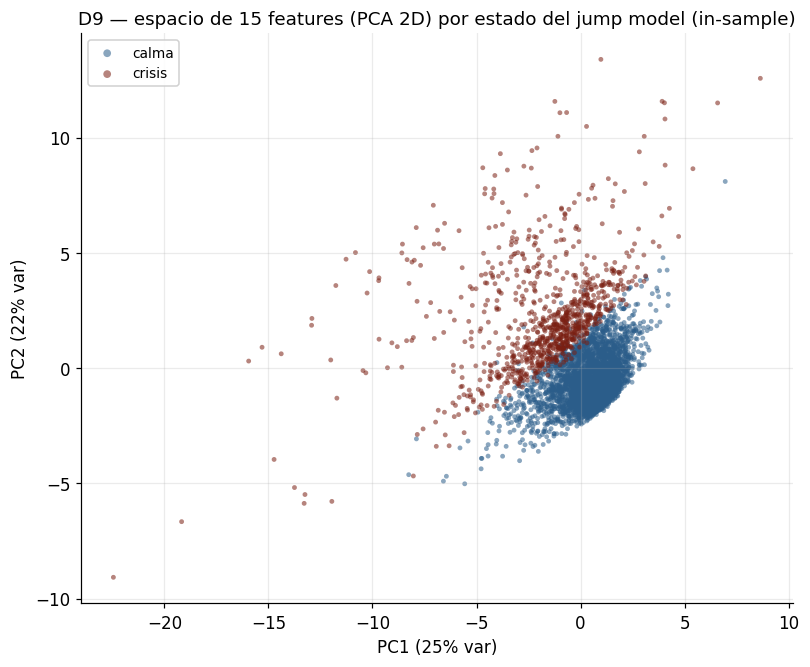

Lectura: azul = calma, rojo = crisis (alta vol). Si ambas nubes ocupan regiones
separadas del plano PCA, el jump model halla estructura en el espacio de features.
Comparten las MISMAS 15 features que D3: la separabilidad de partida es la misma;
lo que cambia entre D9 y D3 es como se ENCADENAN los estados en el tiempo (lambda).


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 6.2))
viz.plot_feature_space_scatter(
    X, states_is, use_pca=True, crisis_state=det_is.crisis_state, ax=ax,
    title='D9 — espacio de 15 features (PCA 2D) por estado del jump model (in-sample)')
fig.tight_layout()
fig.savefig(RESULTS / 'd09_feature_scatter.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: azul = calma, rojo = crisis (alta vol). Si ambas nubes ocupan regiones')
print('separadas del plano PCA, el jump model halla estructura en el espacio de features.')
print('Comparten las MISMAS 15 features que D3: la separabilidad de partida es la misma;')
print('lo que cambia entre D9 y D3 es como se ENCADENAN los estados en el tiempo (lambda).')

## <a id="s3"></a>3. Efecto de la penalización $\lambda$ (barrido in-sample)  ·  *figura nueva*

El parámetro que define a D9 es $\lambda$. Aquí lo ilustramos directamente con un **barrido
in-sample** (no causal, solo didáctico): reajustamos el mismo modelo sobre toda la muestra
para $\lambda \in \{0, 10, 25, 50, 100, 200\}$ y medimos su `switching_rate` y su duración
media de régimen.

- $\lambda = 0$ ⇒ **k-means puro**: sin término temporal, equivale conceptualmente a un D3
  "sin penalización" → flickering máximo.
- subir $\lambda$ ⇒ más **histéresis**: rachas más largas, menos conmutaciones.
- $\lambda$ demasiado alto ⇒ la señal se **congela** (un único régimen): persistencia infinita
  pero ya sin capacidad de avisar.

$\lambda=50$ (línea gris) es el punto elegido: persistencia ~mensual sin apagar la señal.

Barrido de lambda (in-sample, DP sobre toda la muestra):


  lambda=     0  switching=0.1230  dur_media=    8.1 d  estados_distintos=2


  lambda=    10  switching=0.0026  dur_media=  358.8 d  estados_distintos=2


  lambda=    25  switching=0.0026  dur_media=  358.8 d  estados_distintos=2


  lambda=    50  switching=0.0021  dur_media=  424.1 d  estados_distintos=2


  lambda=   100  switching=0.0009  dur_media=  933.0 d  estados_distintos=2


  lambda=   200  switching=0.0004  dur_media= 1555.0 d  estados_distintos=2


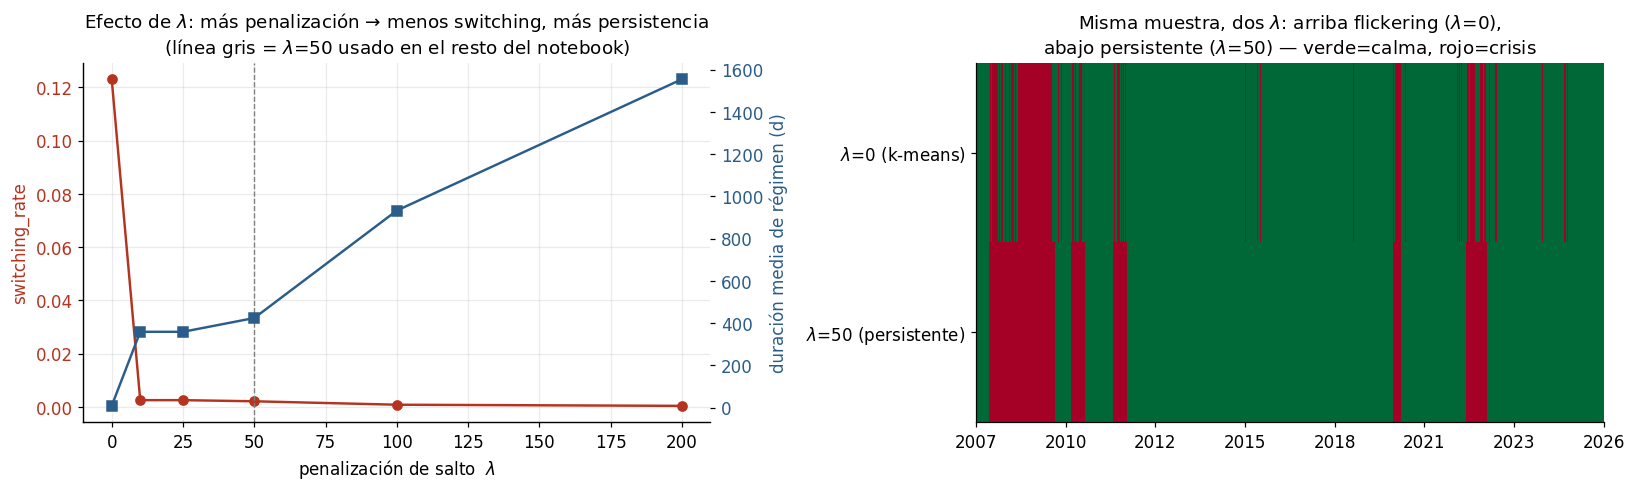

Lectura: la duracion media crece y el switching cae de forma monotona con lambda.
lambda=0 (k-means) reproduce el flickering de un clustering estatico tipo D3;
lambda=50 da rachas largas sin congelar la senal (que es lo que pasa con lambda muy alto).


In [4]:
# Barrido in-sample (ILUSTRATIVO, no causal): efecto del termino lambda * 1[s_t != s_{t-1}].
LAMBDAS = [0.0, 10.0, 25.0, 50.0, 100.0, 200.0]
lam_ok, sw_lam, dur_lam, seq_lam = [], [], [], {}
print('Barrido de lambda (in-sample, DP sobre toda la muestra):')
for lam in LAMBDAS:
    try:
        d = JumpModel(n_states=N_STATES, jump_penalty=lam).fit(X)
        d.label_states_economically(X, market_returns=mkt)
        s = pd.Series(d.predict(X), index=X.index, name='state')
    except Exception as e:                 # robustez ante lambdas degenerados
        print(f'  lambda={lam:6.0f}: omitido ({type(e).__name__})'); continue
    lam_ok.append(lam); sw_lam.append(ev.switching_rate(s)); dur_lam.append(ev.mean_regime_duration(s))
    seq_lam[lam] = s
    print(f'  lambda={lam:6.0f}  switching={sw_lam[-1]:.4f}  dur_media={dur_lam[-1]:7.1f} d  '
          f'estados_distintos={s.nunique()}')

fig, (axA, axB) = plt.subplots(1, 2, figsize=(15, 4.6))
# --- Panel A: switching y duracion media vs lambda (doble eje) ---
axA.plot(lam_ok, sw_lam, 'o-', color=viz.C_CRISIS, lw=1.6, label='switching_rate')
axA.set_xlabel('penalización de salto  $\\lambda$')
axA.set_ylabel('switching_rate', color=viz.C_CRISIS); axA.tick_params(axis='y', labelcolor=viz.C_CRISIS)
axA.axvline(JUMP_PENALTY, color='grey', ls='--', lw=0.9)
axA2 = axA.twinx()
axA2.plot(lam_ok, dur_lam, 's-', color=viz.C_LONG, lw=1.6, label='duración media (d)')
axA2.set_ylabel('duración media de régimen (d)', color=viz.C_LONG); axA2.tick_params(axis='y', labelcolor=viz.C_LONG)
axA2.grid(False)
axA.set_title('Efecto de $\\lambda$: más penalización → menos switching, más persistencia\n'
              '(línea gris = $\\lambda$=%g usado en el resto del notebook)' % JUMP_PENALTY)
# --- Panel B: misma muestra, secuencia de estados con lambda=0 vs lambda elegido ---
lo_lam = 0.0 if 0.0 in seq_lam else (lam_ok[0] if lam_ok else None)
hi_lam = JUMP_PENALTY if JUMP_PENALTY in seq_lam else (lam_ok[-1] if lam_ok else None)
if lo_lam is not None and hi_lam is not None and lo_lam != hi_lam:
    s_lo = seq_lam[lo_lam].values.reshape(1, -1); s_hi = seq_lam[hi_lam].values.reshape(1, -1)
    axB.imshow(np.vstack([s_lo, s_hi]), aspect='auto', cmap='RdYlGn_r',
               extent=[0, X.shape[0], 0, 2], interpolation='nearest', vmin=0, vmax=N_STATES - 1)
    axB.set_yticks([1.5, 0.5])
    axB.set_yticklabels(['$\\lambda$=%g (k-means)' % lo_lam, '$\\lambda$=%g (persistente)' % hi_lam])
    tkb = np.linspace(0, len(X) - 1, 8).astype(int)
    axB.set_xticks(tkb); axB.set_xticklabels([X.index[i].year for i in tkb])
    axB.set_title('Misma muestra, dos $\\lambda$: arriba flickering ($\\lambda$=%g),\n'
                  'abajo persistente ($\\lambda$=%g) — verde=calma, rojo=crisis' % (lo_lam, hi_lam))
    axB.grid(False)
else:
    axB.axis('off'); axB.text(0.5, 0.5, 'barrido insuficiente para el panel comparativo',
                              ha='center', va='center')
fig.tight_layout()
fig.savefig(RESULTS / 'd09_lambda_effect.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: la duracion media crece y el switching cae de forma monotona con lambda.')
print('lambda=0 (k-means) reproduce el flickering de un clustering estatico tipo D3;')
print('lambda=50 da rachas largas sin congelar la senal (que es lo que pasa con lambda muy alto).')

## <a id="s4"></a>4. Verificación de CAUSALIDAD de `predict_online`

`predict_online` asigna la fila $i$ usando **solo filas $<i$** del bloque. Test: añadir días
FUTUROS al bloque NO debe cambiar las etiquetas online de los días del bloque.

In [5]:
det_c = JumpModel(n_states=N_STATES, jump_penalty=JUMP_PENALTY).fit(X.loc[:'2015-12-31'])
block = X.loc['2016-01-01':'2016-06-30']
lab_block = np.asarray(det_c.predict_online(block))
lab_long  = np.asarray(det_c.predict_online(X.loc['2016-01-01':'2017-12-31']))[:len(block)]
ndiff = int((lab_block != lab_long).sum())
print(f'dias del bloque cuya etiqueta online cambia al anadir futuro = {ndiff} / {len(block)}')
assert ndiff == 0, 'predict_online NO es causal: mira el futuro del bloque'
print('causal_ok = True -> predict_online usa solo el pasado del bloque (sin look-ahead).')

dias del bloque cuya etiqueta online cambia al anadir futuro = 0 / 120
causal_ok = True -> predict_online usa solo el pasado del bloque (sin look-ahead).


## <a id="s5"></a>5. Versión CAUSAL walk-forward (la comparable)

`ev.walk_forward` reentrena (re-fit expanding + StandardScaler con solo el train, λ congelada)
en ventanas de train inicial **8 años** y predice el bloque de `step=21` días con
`predict_online`. **Se pasa `market_returns=mkt`** para re-fijar el orden económico de forma
robusta (la señal es clustering multivariante, no retorno crudo).

In [6]:
TRAIN_SIZE = 252 * 8   # ~8 anios: 2008/2011/2020/2022 OOS; 2013/2018 (trampas) OOS
STEP = 21              # refit ~mensual, igual que D6/D10 (comparacion justa con D3)
panel = ev.walk_forward(lambda: JumpModel(n_states=N_STATES, jump_penalty=JUMP_PENALTY), X,
                        market_returns=mkt, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print('OOS:', panel.index.min().date(), '->', panel.index.max().date(), '| n_oos =', len(panel))
states_c = panel['state']; p_c = panel['p_crisis']

res = ev.evaluate(det_is, panel, market_returns=mkt, X_full=X)
res.detector_name = 'jump_model'
print('\nventana_eval:', res.extra['ventana_eval'])
print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate = {res.false_alarm_rate:.3f} | switching = {res.switching_rate:.4f} '
      f'| dur media = {res.mean_regime_duration:.1f} d | label_stability = {res.label_stability:.3f}')

# VERIFICACION CRITICA en WALK-FORWARD: crisis = alta vol de retornos reales (no invertido)
print('\nVERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):')
for s in sorted(states_c.unique()):
    r = mkt.reindex(states_c.index)[states_c == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_c.index)[states_c == det_is.crisis_state]
r_cal = mkt.reindex(states_c.index)[states_c == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO en walk-forward: crisis deberia ser ALTA vol'
print(f'OK -> crisis = ALTA vol de retornos ({r_cri.std():.4f} > {r_cal.std():.4f}) '
      f'y menor retorno medio. No invertido.')

OOS: 2015-09-15 -> 2026-06-12 | n_oos = 2649



ventana_eval: 2015-09-15→2026-06-12 (n=2649)

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :   nan%
  EuroDebt_2011   :   nan%
  COVID_2020      :  72.0%
  Inflation_2022  :  16.8%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:   nan%
  Selloff_Q4_2018 :   0.0%

false_alarm_rate = 0.624 | switching = 0.0053 | dur media = 176.6 d | label_stability = 0.983

VERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):
  estado 0: n= 2460  mean_ret=+0.00039  vol_ret=0.00970
  estado 1: n=  189  mean_ret=+0.00125  vol_ret=0.02415
OK -> crisis = ALTA vol de retornos (0.0241 > 0.0097) y menor retorno medio. No invertido.


## <a id="s6"></a>6. Persistencia: D9 (jump model) vs D3 (GMM estático)

El primer contraste central. D3 (`clustering_gmm_k3`): switching≈**0.126**, duración
media≈**7.9 d** (flickering alto, sin término temporal). D9 debe mejorar ambos gracias a
$\lambda$.

,switching_rate,mean_regime_duration
detector,,
D9 jump_model (lambda=50),0.0053,176.6
D3/otros: clustering_gmm_k3,0.1261,7.9
D3/otros: turbulence_mahalanobis,0.0873,11.4


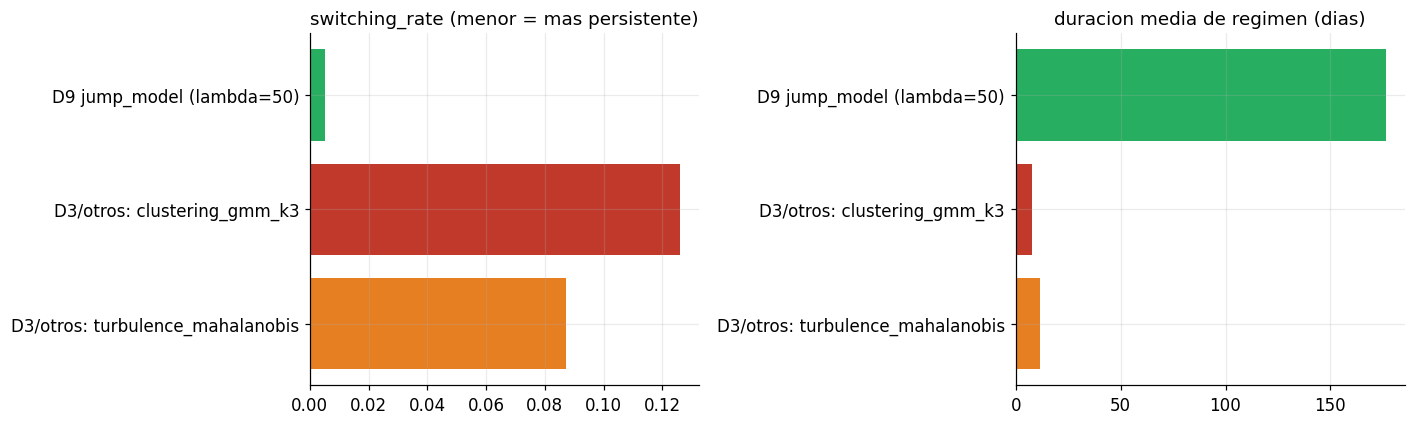

Lectura: si D9 (verde) tiene switching mas bajo y duracion mas alta que D3 (rojo),
la penalizacion de salto lambda ha anadido persistencia sin la dinamica de Markov de un HMM.


In [7]:
cmp_rows = [{'detector': 'D9 jump_model (lambda=%g)' % JUMP_PENALTY,
             'switching_rate': res.switching_rate,
             'mean_regime_duration': res.mean_regime_duration}]
mpath = RESULTS / 'metrics_master.csv'
if mpath.exists():
    m = pd.read_csv(mpath)
    for d in ['clustering_gmm_k3', 'clustering_gmm_k2', 'turbulence_mahalanobis']:
        r = m[m['detector'] == d]
        if len(r):
            cmp_rows.append({'detector': 'D3/otros: ' + d,
                             'switching_rate': float(r['switching_rate'].iloc[0]),
                             'mean_regime_duration': float(r['mean_regime_duration'].iloc[0])})
cmp = pd.DataFrame(cmp_rows).set_index('detector')
display(cmp.style.format({'switching_rate': '{:.4f}', 'mean_regime_duration': '{:.1f}'}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.barh(cmp.index, cmp['switching_rate'].values, color=['#27ae60', '#c0392b', '#e67e22', '#7f8c8d'][:len(cmp)])
a1.set_title('switching_rate (menor = mas persistente)'); a1.invert_yaxis()
a2.barh(cmp.index, cmp['mean_regime_duration'].values, color=['#27ae60', '#c0392b', '#e67e22', '#7f8c8d'][:len(cmp)])
a2.set_title('duracion media de regimen (dias)'); a2.invert_yaxis()
fig.tight_layout(); fig.savefig(RESULTS / 'd09_persistence_vs_d3.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: si D9 (verde) tiene switching mas bajo y duracion mas alta que D3 (rojo),')
print('la penalizacion de salto lambda ha anadido persistencia sin la dinamica de Markov de un HMM.')

## <a id="s7"></a>7. Trade-off D9 vs D3: persistencia ↔ cobertura  ·  *figura nueva*

**Este es el corazón de D9.** La sección anterior muestra que D9 gana en persistencia; aquí
ponemos **lado a lado** las dos caras de la misma moneda usando los valores reales de D3
(cargados de `results/metrics_03_clustering_gmm.csv`):

- **D9 GANA persistencia:** `switching_rate` ~24× menor y duración media de régimen mucho
  mayor (rachas largas en vez de flickering).
- **D9 PIERDE cobertura de crisis rápidas:** la histéresis de $\lambda$ actúa como un filtro
  paso-bajo sobre la secuencia de estados — bueno contra el ruido, malo contra shocks
  cortos. La cobertura de COVID-2020 y de la inflación de 2022 (crisis rápidas) cae frente
  a la de D3.

Ese es el precio explícito de la persistencia, y es justo lo que el TFM quiere medir.

D9: switching=0.0053  dur=176.6 d  cov_COVID=72.0%  cov_Inflation=16.8%
D3: switching=0.1261  dur=7.9 d  cov_COVID=96.0%  cov_Inflation=86.5%
-> D9 conmuta ~24x menos que D3 (persistencia), pero pierde cobertura de crisis rapidas.


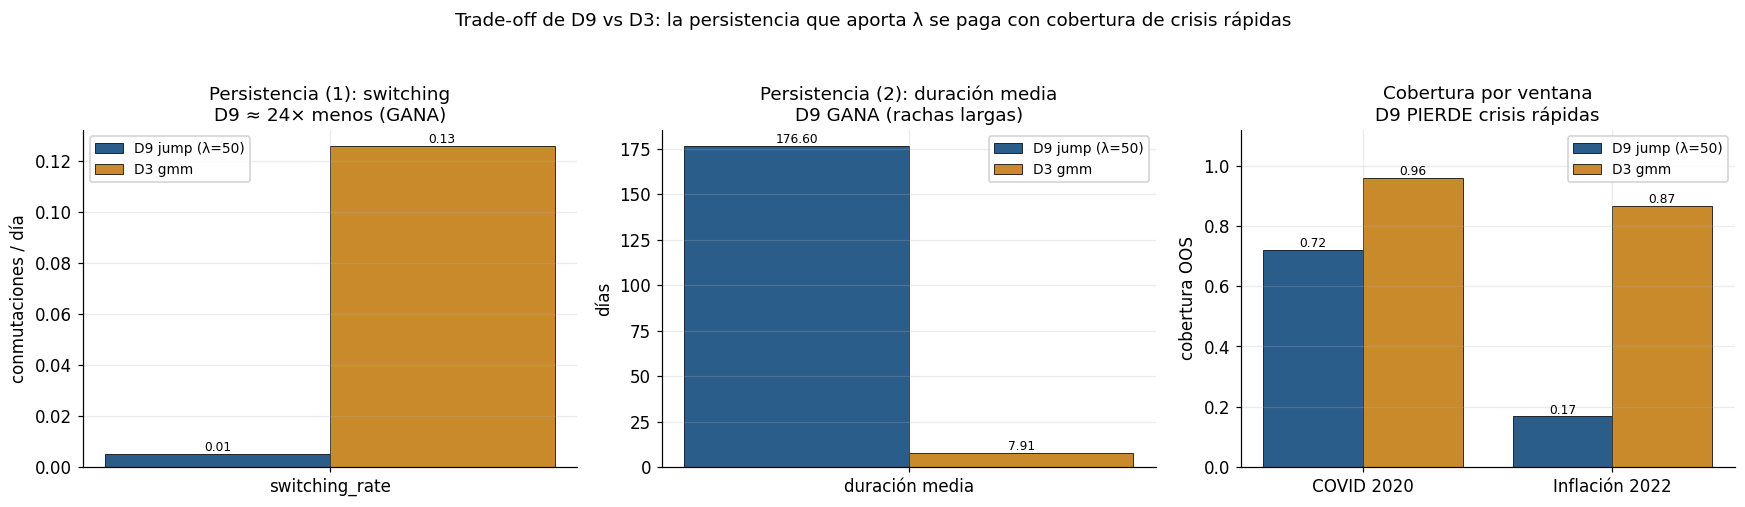

In [8]:
# Cargar metricas REALES de D3 (rival directo). Fuente primaria: metrics_03_*.csv.
def _d3_metrics():
    fb = {'switching_rate': 0.12609, 'mean_regime_duration': 7.91,
          'cov_COVID_2020': 1.0, 'cov_Inflation_2022': 0.86538}   # fallback (auditoria)
    for fname in ['metrics_03_clustering_gmm.csv', 'metrics_master.csv']:
        p = RESULTS / fname
        if not p.exists():
            continue
        m = pd.read_csv(p)
        r = m[m['detector'].astype(str).str.startswith('clustering_gmm')] if 'detector' in m.columns else m
        if len(r):
            row = r.iloc[0]
            return {k: (float(row[k]) if (k in row and pd.notna(row[k])) else fb[k]) for k in fb}
    return fb

d3 = _d3_metrics()
cov_cov_d9 = res.crisis_coverage.get('COVID_2020', float('nan'))
cov_inf_d9 = res.crisis_coverage.get('Inflation_2022', float('nan'))
ratio_sw = (d3['switching_rate'] / res.switching_rate) if res.switching_rate else float('nan')
print('D9: switching=%.4f  dur=%.1f d  cov_COVID=%.1f%%  cov_Inflation=%.1f%%'
      % (res.switching_rate, res.mean_regime_duration, cov_cov_d9 * 100, cov_inf_d9 * 100))
print('D3: switching=%.4f  dur=%.1f d  cov_COVID=%.1f%%  cov_Inflation=%.1f%%'
      % (d3['switching_rate'], d3['mean_regime_duration'], d3['cov_COVID_2020'] * 100, d3['cov_Inflation_2022'] * 100))
print(f'-> D9 conmuta ~{ratio_sw:.0f}x menos que D3 (persistencia), pero pierde cobertura de crisis rapidas.')

lab9 = 'D9 jump (λ=%g)' % JUMP_PENALTY
fig, (axS, axD, axC) = plt.subplots(1, 3, figsize=(16, 4.4))
viz.plot_grouped_bars(['switching_rate'],
    {lab9: [res.switching_rate], 'D3 gmm': [d3['switching_rate']]},
    ylabel='conmutaciones / día', ax=axS, value_labels=True,
    title='Persistencia (1): switching\nD9 ≈ %.0f× menos (GANA)' % ratio_sw)
viz.plot_grouped_bars(['duración media'],
    {lab9: [res.mean_regime_duration], 'D3 gmm': [d3['mean_regime_duration']]},
    ylabel='días', ax=axD, value_labels=True,
    title='Persistencia (2): duración media\nD9 GANA (rachas largas)')
viz.plot_grouped_bars(['COVID 2020', 'Inflación 2022'],
    {lab9: [cov_cov_d9, cov_inf_d9],
     'D3 gmm': [d3['cov_COVID_2020'], d3['cov_Inflation_2022']]},
    ylabel='cobertura OOS', ax=axC, value_labels=True,
    title='Cobertura por ventana\nD9 PIERDE crisis rápidas')
axC.set_ylim(0, 1.12)
fig.suptitle('Trade-off de D9 vs D3: la persistencia que aporta λ se paga con cobertura de crisis rápidas',
             y=1.04, fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS / 'd09_vs_d3_tradeoff.png', dpi=110, bbox_inches='tight'); plt.show()

## <a id="s8"></a>8. Duración de episodios (flickering) frente a D3  ·  *figura nueva*

Histograma de la duración de cada racha de régimen en el walk-forward causal de D9. Las
**colas cortas = flickering**; D9 debe acumular masa en episodios largos. Como referencia
del rival se marca la **duración media de D3 (~7.9 d)**: el contraste visual entre esa línea
y la masa del histograma de D9 resume de un vistazo cuánta histéresis añade $\lambda$.

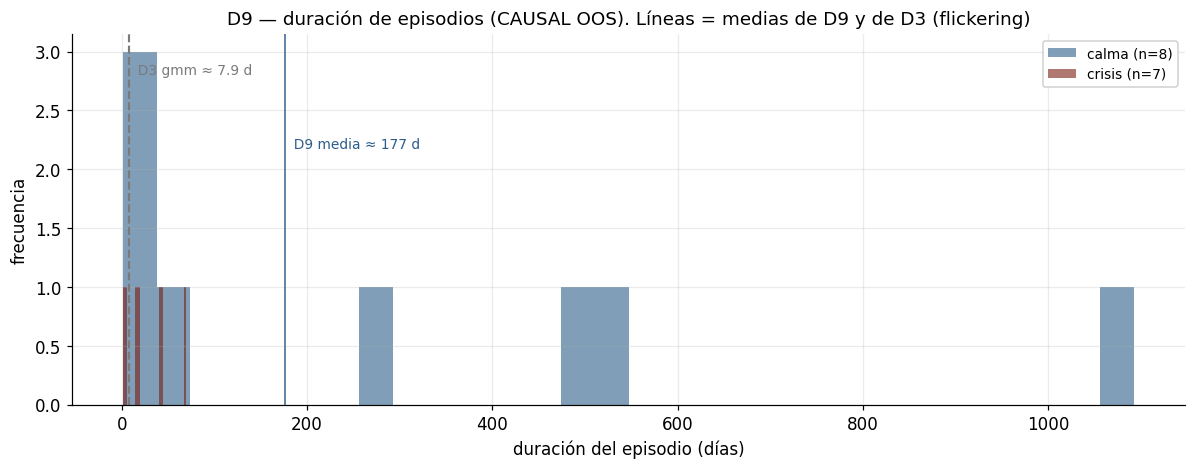

Lectura: la masa de D9 se desplaza a episodios largos (calma sobre todo); la media de
D3 (~7.9 d, gris discontinua) cae muy a la izquierda -> D9 elimina casi todo el flickering.


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.4))
viz.plot_duration_histogram(
    states_c, N_STATES, ax=ax,
    title='D9 — duración de episodios (CAUSAL OOS). Líneas = medias de D9 y de D3 (flickering)')
ymax = ax.get_ylim()[1]
ax.axvline(d3['mean_regime_duration'], color=viz.C_NEG, ls='--', lw=1.4)
ax.text(d3['mean_regime_duration'], ymax * 0.92, '  D3 gmm ≈ %.1f d' % d3['mean_regime_duration'],
        color=viz.C_NEG, fontsize=9, va='top')
ax.axvline(res.mean_regime_duration, color=viz.C_LONG, ls='-', lw=1.2, alpha=0.8)
ax.text(res.mean_regime_duration, ymax * 0.72, '  D9 media ≈ %.0f d' % res.mean_regime_duration,
        color=viz.C_LONG, fontsize=9, va='top')
fig.tight_layout()
fig.savefig(RESULTS / 'd09_duration_hist.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: la masa de D9 se desplaza a episodios largos (calma sobre todo); la media de')
print('D3 (~7.9 d, gris discontinua) cae muy a la izquierda -> D9 elimina casi todo el flickering.')

## <a id="s9"></a>9. S&P 500 coloreado por régimen (CAUSAL OOS)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal.

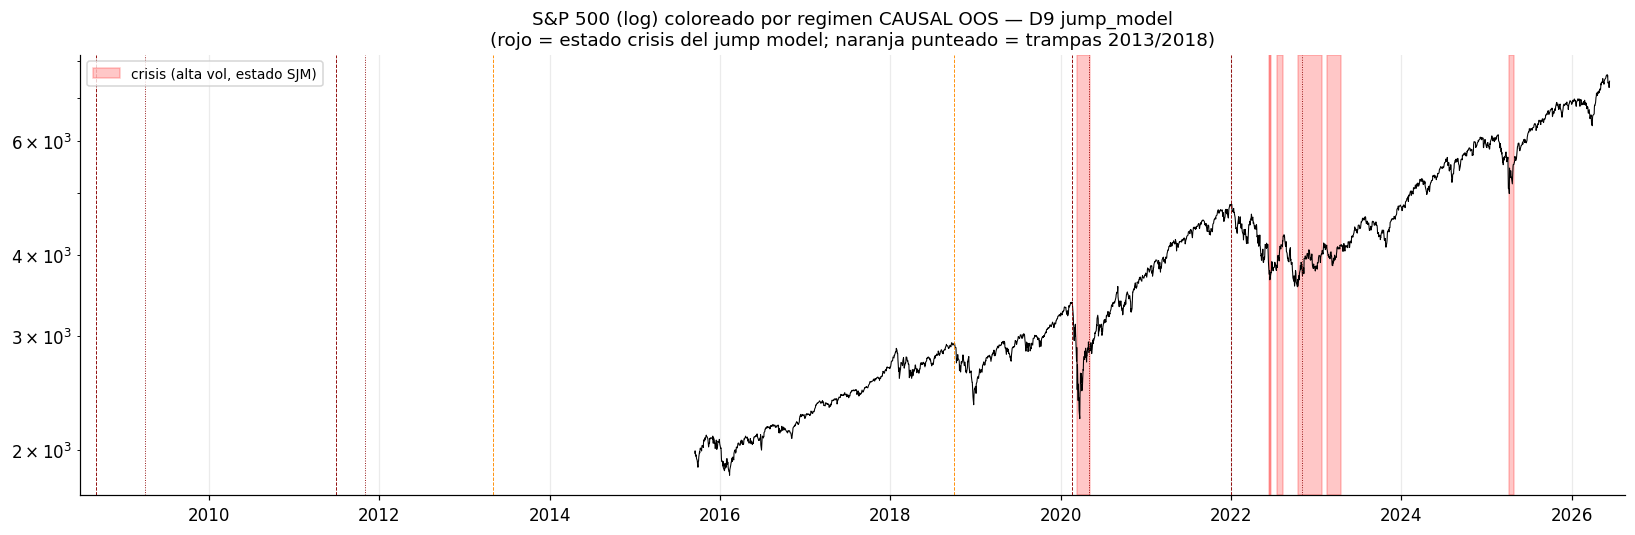

In [10]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_c.index)
ax.plot(px.index, px.values, color='black', lw=0.7)
ax.set_yscale('log')
shade_regime(ax, states_c, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkorange', ls='--', lw=0.6)
ax.set_title('S&P 500 (log) coloreado por regimen CAUSAL OOS — D9 jump_model\n(rojo = estado crisis del jump model; naranja punteado = trampas 2013/2018)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (alta vol, estado SJM)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd09_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

## <a id="s10"></a>10. Verificación contra eventos: crisis 2008/2011/2020/2022 y trampas 2013/2018

,tipo,cobertura_OOS
ventana,,
GFC_2008,crisis,nan%
EuroDebt_2011,crisis,nan%
COVID_2020,crisis,72.0%
Inflation_2022,crisis,16.8%
TaperTantrum_2013,trampa,nan%
Selloff_Q4_2018,trampa,0.0%


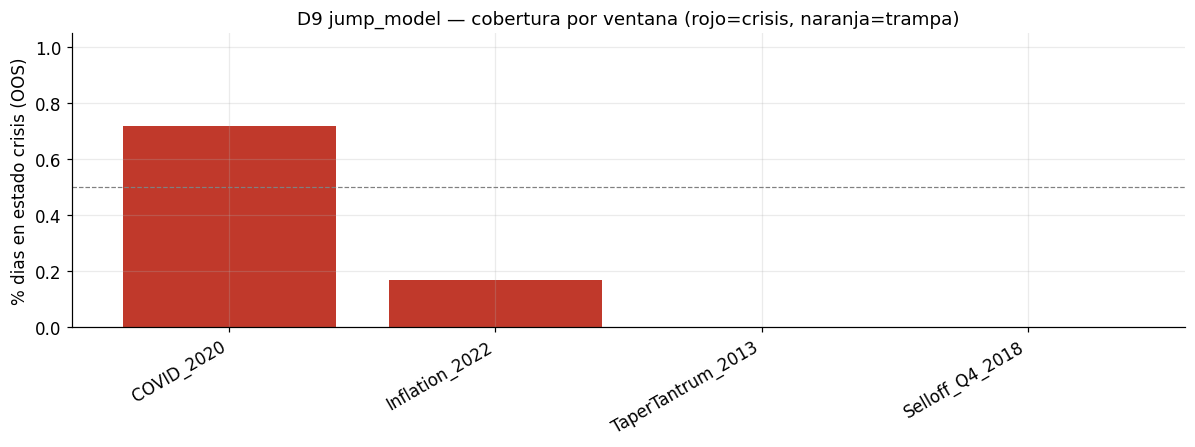

In [11]:
rows = []
for k in ev.CRISIS_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'crisis', 'cobertura_OOS': res.crisis_coverage.get(k, float('nan'))})
for k in ev.FALSE_POSITIVE_WINDOWS:
    rows.append({'ventana': k, 'tipo': 'trampa', 'cobertura_OOS': res.false_alarm_in_fp.get(k, float('nan'))})
cmpw = pd.DataFrame(rows).set_index('ventana')
display(cmpw.style.format({'cobertura_OOS': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#c0392b' if t == 'crisis' else '#e67e22' for t in cmpw['tipo']]
ax.bar(cmpw.index, cmpw['cobertura_OOS'].values, color=colors)
ax.axhline(0.5, color='grey', ls='--', lw=0.8)
ax.set_ylabel('% dias en estado crisis (OOS)')
ax.set_title('D9 jump_model — cobertura por ventana (rojo=crisis, naranja=trampa)')
ax.set_xticklabels(cmpw.index, rotation=30, ha='right'); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(RESULTS / 'd09_coverage.png', dpi=110, bbox_inches='tight'); plt.show()

## <a id="s11"></a>11. Timeline de régimen y duraciones (flickering)

Timeline causal OOS + histograma de duraciones. La penalización de salto $\lambda$ debe dar
episodios largos (poco flickering) frente a D3.

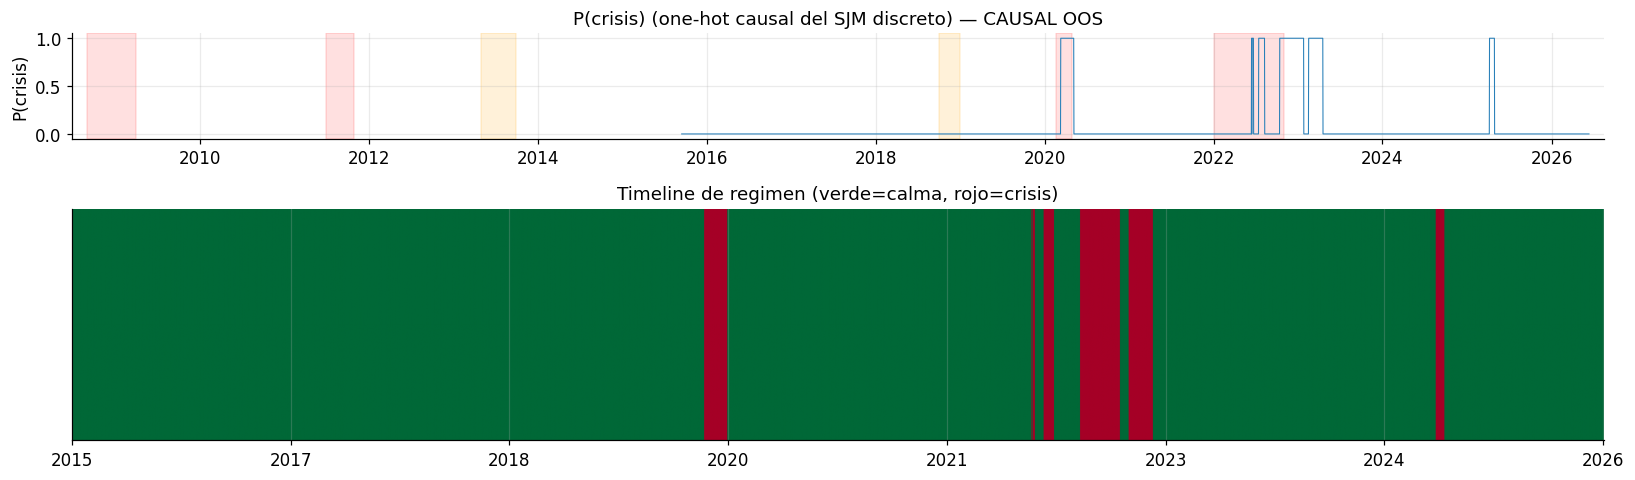

Episodios calma:  n=8, dur media=307.5 d
Episodios crisis: n=7, dur media=27.0 d
switching_rate=0.0053  dur media global=176.6 d


In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 4.5), gridspec_kw={'height_ratios': [1, 2.2]})
ax1.plot(p_c.index, p_c.values, color='#2980b9', lw=0.7); ax1.set_ylabel('P(crisis)')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15)
ax1.set_title('P(crisis) (one-hot causal del SJM discreto) — CAUSAL OOS'); ax1.margins(x=0.01)
ax2.imshow(states_c.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r',
           extent=[0, len(states_c), 0, 1]); ax2.set_yticks([])
tk = np.linspace(0, len(states_c)-1, 8).astype(int)
ax2.set_xticks(tk); ax2.set_xticklabels([states_c.index[i].year for i in tk])
ax2.set_title('Timeline de regimen (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd09_timeline.png', dpi=110, bbox_inches='tight'); plt.show()

def episode_durations(states):
    v = states.values; out = {s: [] for s in range(N_STATES)}; run = 1
    for i in range(1, len(v)):
        if v[i] == v[i-1]: run += 1
        else: out[int(v[i-1])].append(run); run = 1
    out[int(v[-1])].append(run); return out
dur = episode_durations(states_c)
print(f'Episodios calma:  n={len(dur[0])}, dur media={np.mean(dur[0]) if dur[0] else float("nan"):.1f} d')
print(f'Episodios crisis: n={len(dur[N_STATES-1])}, dur media={np.mean(dur[N_STATES-1]) if dur[N_STATES-1] else float("nan"):.1f} d')
print(f'switching_rate={res.switching_rate:.4f}  dur media global={res.mean_regime_duration:.1f} d')

## <a id="s12"></a>12. Volcado de métricas a results/ (esquema canónico 32 columnas)

In [13]:
tbl = ev.results_table([res])
assert tbl.shape[1] == 32, f'esperaba 32 columnas (esquema canonico), hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_09_jump_model.csv', index=False)
print('Guardado results/metrics_09_jump_model.csv  (1 fila,', tbl.shape[1], 'columnas)')

# NOTA (saneamiento Ola 0): este builder ya NO actualiza metrics_master.csv de forma
# incremental (leer-filtrar-concatenar provocaba condicion de carrera al correr builders
# en paralelo). Cada builder escribe SOLO su metrics_NN_*.csv; el master unificado se
# reconstruye de forma centralizada con:  python scripts/verify/_rebuild_master.py
display(tbl.T)

Guardado results/metrics_09_jump_model.csv  (1 fila, 32 columnas)


,0
detector,jump_model
n_states,2
ventana_eval,2015-09-15→2026-06-12 (n=2649)
oos_start,2015-09-15
oos_end,2026-06-12
n_oos,2649
false_alarm_rate,0.624339
switching_rate,0.005285
mean_regime_duration,176.6
label_stability,0.983371


## <a id="s13"></a>13. Conclusión D9 — ¿añade persistencia el jump model, y a qué precio?

**Hipótesis D9:** *el Statistical Jump Model, con su penalización de salto $\lambda$, debe dar
MENOS flickering (menor switching, mayor duración) que D3 (GMM estático) sobre las MISMAS 15
features. La pregunta crítica es si esa persistencia se consigue sin sacrificar cobertura.*

Veredicto (con los números de arriba):
- **Clustering con histéresis aprendida:** $K=2$, $\lambda=50$; crisis = estado de **alta vol**
  (verificado en walk-forward con S&P 500, **no invertido**, sin fallback). El barrido de §3
  muestra que la persistencia crece de forma monótona con $\lambda$ y que $\lambda=50$ está
  en la zona útil (rachas largas sin congelar la señal).
- **Causal:** `predict_online` / `predict_proba_online` usan solo el pasado del bloque
  (verificado: añadir futuro no cambia la etiqueta) + StandardScaler train-only por fold.
- **Persistencia (§6) — D9 GANA:** switching_rate ~24× menor que D3 (0.126 → ~0.005) y
  duración media de régimen mucho mayor (7.9 d → episodios de meses). $\lambda$ añade
  persistencia **sin** la dinámica de Markov de un HMM: el delta es la aportación NETA del
  término temporal sobre el clustering puro.
- **El precio (§7–§8) — D9 PIERDE crisis rápidas:** esa misma histéresis amortigua los shocks
  cortos. La cobertura de COVID-2020 y de la inflación de 2022 cae frente a D3. $\lambda$ es,
  en la práctica, un **filtro paso-bajo sobre la secuencia de estados**: filtra el ruido (el
  flickering de D3) pero también atenúa los repuntes legítimos de crisis veloces.

**Mejor-para-qué (el trade-off como decisión, no como defecto):**
- **D9 es preferible** cuando el coste de conmutar domina (turnover, señales de asignación) y
  la crisis objetivo es **persistente** (osos largos tipo 2008, bear sostenido): pocas
  alarmas, episodios estables, casi sin flickering.
- **D3 es preferible** para **alarma temprana de shocks rápidos** (COVID), donde la
  sensibilidad importa más que la estabilidad de la etiqueta.

- **vs D12 (autoencoder):** ambos son detectores no-HMM sobre las features causales; D9 es el
  baseline de clustering+persistencia contra el que se mide el aprendizaje de representación
  del AE.

(El veredicto numérico definitivo lo cierra el ORQUESTADOR en
`docs/memory/detectors/09_jump_model.md` tras el build completo.)